In [76]:
import numpy as np
import SimpleITK as sitk
import csv,os,json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from collections import defaultdict
from tqdm import tqdm

In [68]:
def load_WIMA():
    # input_file = "./WIMA-BODY.csv"
    df_part1 = pd.read_csv('WIMA_part1.csv')
    df_part2 = pd.read_csv('WIMA_part2.csv')
    df = pd.concat([df_part1, df_part2], ignore_index=True)
    data_dict = {}
    # 逐行处理数据并提取
    for _, row in df.iterrows():
        category = row[0]
        slope = float(row[1])
        intercept = float(row[2])
        p_value = float(row[3])
        r_value = float(row[4])
        std_err = float(row[5])

        # 将列 6 和列 7 的数据处理为列表
        Xdata = np.array(list(map(float, row[6].split(','))))
        Ydata = np.array(list(map(float, row[7].split(','))))
        
        # 将处理后的数据存储到字典
        data_dict[category] = [slope, intercept, p_value, r_value, std_err, Xdata, Ydata]

    return data_dict

In [70]:
def extract_suv_based_roi(suv,atlas,savepath):
    atlas = sitk.GetArrayFromImage(atlas)
    suv = sitk.GetArrayFromImage(suv)
    with open("./mpum_categorylist.json","r") as f:
        atlasinfo = json.load(f)
    op = {}
    for i in tqdm(range(3,215)):
        tmp = suv[atlas == i]
        if len(tmp) == 0:
            continue
        meansuv = np.mean(tmp)
        maxsuv = np.max(tmp)
        bins = np.arange(0, 30.1, 0.1)
        bins = np.append(bins, np.inf)
        hist, bin_edges = np.histogram(tmp, bins=bins)
        hist = [int(h) for h in list(hist)]
        op[atlasinfo[str(i)]] = {"meansuv":float(meansuv),"maxsuv":float(maxsuv),"hist":hist}
    with open(savepath+"suv_roi_feature.json","w") as f:
        json.dump(op,f)
    return op

In [71]:

def detect_anomaly(WIMA,op,mode):
    mode = "brain"
    organnames=[]
    anomaly_pairs = []
    anomaly_value_cases = []
    true_labels = []
    
    number = 0
    with open("./mpum_categorylist.json","r") as f:
        atlasinfo = json.load(f)
    if mode == "brain":
        for i in range(132,215): # 3,132,215
            organnames.append(atlasinfo[str(i)])
    if mode == "body":
        for i in range(3,132): # 3,132,215
            organnames.append(atlasinfo[str(i)])
    if mode == "all":
        for i in range(3,215): # 3,132,215
            organnames.append(atlasinfo[str(i)])
    data = {}
    number = 0
    outlier_number = 0
    error_sum = []
    anomaly_value = []
    
    for i,o1 in enumerate(organnames):
        for j,o2 in enumerate(organnames[i+1:]):
            if op.__contains__(o1) and op.__contains__(o2):
                x = op[o1]["maxsuv"]
                y = op[o2]["maxsuv"]
                if not WIMA.__contains__(o1+"_"+o2):
                    continue
                params = WIMA[o1+"_"+o2]
                error = y - (params[0] * x + params[1])
                a = (x-np.mean(params[5])) ** 2 / np.sum((params[5] - np.mean(params[5])) ** 2)
                RSE = np.sum((params[6]-(params[5] * params[0] + params[1])) ** 2)/(len(params[5]-2))
                RSE = RSE ** 0.5
                r = error / (RSE * (1+1/len(params[5]) + a  )**0.5)
                error_sum.append(abs(r))
                anomaly_value.append((o1,o2,abs(r)))
    return anomaly_value


In [72]:
from collections import Counter, defaultdict
import time
def process_connections(connections):
    # 创建字典，统计每个器官的出现次数
    region_counts = Counter(region for pair in connections for region in pair)

    # 保存原始连接信息
    adjacency_list = defaultdict(list)
    for a, b in connections:
        adjacency_list[a].append(b)
        adjacency_list[b].append(a)

    # 核心器官和参照器官的分类
    core_regions = []
    reference_regions = defaultdict(list)

    while region_counts:
        # 找到出现次数最多的核心器官
        core_region = region_counts.most_common(1)[0][0]
        core_regions.append(core_region)

        # 减少与核心器官直接连接的器官的次数，并记录参照器官
        for adjacent in adjacency_list[core_region]:
            region_counts[adjacent] -= 1
            reference_regions[core_region].append(adjacent)
            # 如果相邻节点次数减到0，则从列表中删除
            if region_counts[adjacent] <= 1:
                del region_counts[adjacent]
        # 移除已处理的核心器官
        del region_counts[core_region]
    region_counts = Counter(region for pair in connections for region in pair)
    return core_regions, region_counts

In [73]:


def plot_anomaly_pattern(suv,seg,mode='brain'):
    centroids = {}
    if mode == "brain":
        regions_to_plot = range(132, 215)
    if mode == "body":
        regions_to_plot = range(3,132)
    if mode == "all":
        regions_to_plot = range(3,215)
    
    
    with open("./mpum_categorylist.json","r") as f:
        atlasinfo = json.load(f)
    for region in tqdm(regions_to_plot):
        mask = (seg == region)
        if np.max(mask):
            centroid = center_of_mass(mask)
            centroids[atlasinfo[str(region)]] = centroid
    
    axis1 = 1
    axis2 = 2
    axis3 = 0
    
    centroids_2d = [(int(c[axis2]), int(c[axis1])) for c in centroids.values()]  # 提取 x, y 坐标
    plt.figure(figsize=(7,7))
    plt.imshow(np.log(np.max(suv,axis=axis3)+1), cmap='gray')
    
    for centroid in centroids_2d:
        plt.scatter(centroid[0], centroid[1], color='g', s=4)  # 在每个质心位置绘制一个lv点
    
    valid_connections = []
    for d in anomaly_value:
        o1, o2 = d[0], d[1]
        anomaly_ratio = d[2]
        if o1 in centroids and o2 in centroids:
            if anomaly_ratio > 3:
                valid_connections.append((o1, o2))
    connection_counts = defaultdict(int)
    for o1, o2 in valid_connections:
        connection_counts[o1] += 1
        connection_counts[o2] += 1
    core_regions, region_counts = process_connections(valid_connections)
    anomaly_centroid = set()  # 使用集合避免重复
    
    for o1, o2 in valid_connections:
        if connection_counts[o1] > 1 or connection_counts[o2] > 1:
            x1, y1 = int(centroids[o1][axis2]), int(centroids[o1][axis1])
            x2, y2 = int(centroids[o2][axis2]), int(centroids[o2][axis1])
            if o1 not in anomaly_centroid:
                if o1 in core_regions:
                    plt.scatter(x1,y1, color='r', s=region_counts[o1]**0.5+7)
                else:
                    plt.scatter(x1,y1, color='blue', s=7)
            if o2 not in anomaly_centroid:
                if o2 in core_regions and o2 not in anomaly_centroid:
                    plt.scatter(x2,y2, color='r', s=region_counts[o2]**0.5+7)
                else:
                    plt.scatter(x2,y2, color='blue', s=7)
            plt.plot([x1, x2], [y1, y2], color='red', linewidth=0.5, alpha=0.7)
            anomaly_centroid.add(o1)
            anomaly_centroid.add(o2)
            # print(o1, o2)
    
    # # 绘制质心
    centroids_2d = [(int(c[axis2]), int(c[axis1])) for n,c in centroids.items() if n in anomaly_centroid]  # 提取 x, y 坐标
    plt.axis("off")
    plt.savefig("./anomaly_pattern_visualization.png",dpi=300)
    plt.show()

/tmp/ipykernel_2914806/1965196918.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  category = row[0]
/tmp/ipykernel_2914806/1965196918.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = float(row[1])
/tmp/ipykernel_2914806/1965196918.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = float(row[2])
/tmp/ipykernel_2914806/1965196918.py:12: FutureWarning: Series.__getitem__ treating keys as positions is depre

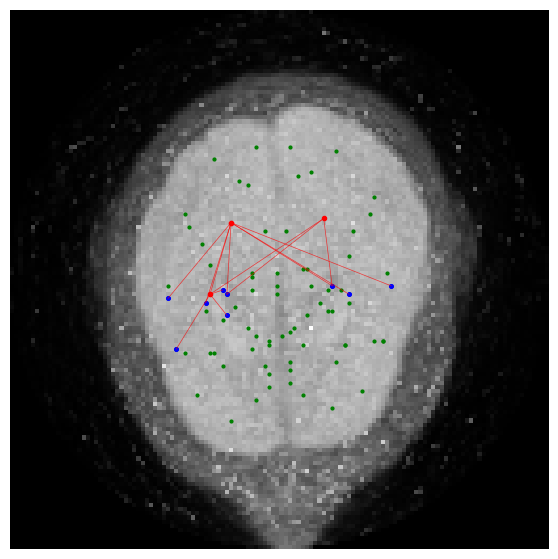

In [75]:
WIMA = load_WIMA()

# suv = sitk.ReadImage("./sampledata/CN_suv_brain.nii.gz")
# seg = sitk.ReadImage("./sampledata/CN_suv_brain_seg.nii.gz")

suv = sitk.ReadImage("./sampledata/EMCI_suv_brain.nii.gz")
seg = sitk.ReadImage("./sampledata/EMCI_suv_brain_seg.nii.gz")

# suv = sitk.ReadImage("./sampledata/AD_suv_brain.nii.gz")
# seg = sitk.ReadImage("./sampledata/AD_suv_brain_seg.nii.gz")
op = extract_suv_based_roi(suv,seg,"sampledata/")

anomaly_value = detect_anomaly(WIMA,op,mode='brain')
print(anomaly_value)
suv = sitk.GetArrayFromImage(suv)
seg = sitk.GetArrayFromImage(seg)

plot_anomaly_pattern(suv,seg,mode='brain')